In [2]:

import random
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh

from sklearn.metrics import classification_report, roc_auc_score
from scipy import interpolate
from sklearn.metrics import roc_curve, auc
from cycler import cycler
# from awkward import ak

import uproot ## means uproot4
import sklearn.metrics as m

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)


CustNano = {
    "GluGlu"       : "/data/pubfs/zhaoyz/CustNano/2018/Signal_MERGED/GluGluHToWW_Pt-200ToInf_M-125_TuneCP5_MINLO_13TeV-powheg-pythia8_RunIISummer20UL18MiniAODv2-106X_upgrade2018_realistic_v16_L1v1-v2/MERGED.root",
    # "VBF"          : "/data/pubfs/zhaoyz/CustNano/2018/Signal_MERGED/VBFHToWWToAny_M-125_TuneCP5_withDipoleRecoil_13TeV-powheg-jhugen751-pythia8_RunIISummer20UL18MiniAODv2-106X_upgrade2018_realistic_v16_L1v1-v2/MERGED.root",
    # "ttH"          : "/data/pubfs/zhaoyz/CustNano/2018/Signal_MERGED/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL18MiniAODv2-106X_upgrade2018_realistic_v16_L1v1-v2/MERGED.root",
    # "HWminus"      : "/data/pubfs/zhaoyz/CustNano/2018/Signal_MERGED/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL18MiniAODv2-106X_upgrade2018_realistic_v16_L1v1-v2/MERGED.root",
    # "HWplus"       : "/data/pubfs/zhaoyz/CustNano/2018/Signal_MERGED/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL18MiniAODv2-106X_upgrade2018_realistic_v16_L1v1-v2/MERGED.root",
    # "HZ"           : "/data/pubfs/zhaoyz/CustNano/2018/Signal_MERGED/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL18MiniAODv2-106X_upgrade2018_realistic_v16_L1v1-v2/MERGED.root",
}
samples = {process : {} for process in CustNano}
for process in CustNano:
    samples[process] = uproot.lazy({CustNano[process]: "Events" }) ## lazy means lazy computation style
    # for var in ak_arrays.fields:
    #     if "HLT" in var or "FatJet" in var:
    #         events[year][var] = ak_arrays[var]

In [5]:
samples["VBF"]

<Array [{run: 1, ... L1simulation_step: True}] type='3000000 * {"run": uint32, "...'>

In [2]:
#Calculate weight one by one.
CustNanoXS = {
    # '2017' : ["/data/pubfs/zhaoyz/CustNano/2017/Data/JetHT_Run2017D-UL2017_MiniAODv2-v1/out_8*.root"],    
    "GluGlu"       : 0.1007,
    "VBF"          : 0.8127,
    "ttH"          : 0.21,
    "HWminus"      : 0.116,
    "HWplus"       : 0.186,
    "HZ"           : 0.205,
}
# WeightDict = {process : float for process in CustNanoXS}


In [3]:
CutFlowValueWeighted = {process : np.zeros(7) for process in CustNanoXS}

In [4]:
#Document the weight of each process.
CustNanoWeight = {
    "GluGlu"       : 0.0112,
    "VBF"          : 0.0162,
    "ttH"          : 0.00175,
    "HWminus"      : 0.000696,
    "HWplus"       : 0.00113,
    "HZ"           : 0.00125,
}

In [ ]:
samples_i = samples["VBF"]
samples_i = samples_i[samples_i['nFatJet'] > 0] 
PT_200 = samples_i['FatJet_pt']>200
print(PT_200)
Eta_2p4 = np.abs(samples_i['FatJet_eta']<2.4)
print(Eta_2p4)
JetCut = PT_200 & Eta_2p4
print(JetCut)
Nj8_i = np.sum(JetCut==True,axis=1)
print(Nj8_i)


[[False], [False], [False], [True], ... False], [True], [True, True], [False]]
[[True], [True], [True], [True], ... True, True], [True], [True, True], [True]]
[[False], [False], [False], [True], ... False], [True], [True, True], [False]]
[0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, ... 2, 0, 1, 1, 1, 0, 2, 1, 0, 1, 1, 2, 0]


In [10]:
# samples_i = samples["VBF"][samples["VBF"]['nFatJet'] > 0] 
# Nj8_i = np.sum(samples_i['FatJet_pt']>200,axis=1)

In [12]:
# samples_i

<Array [{run: 1, ... L1simulation_step: True}] type='362251 * {"run": uint32, "l...'>

In [38]:
# samples_ii = samples_i[(Nj8_i == 2) | (Nj8_i == 3)]

In [24]:
# maxarr = np.max(samples_ii['FatJet_pt'],axis=1)>400

In [28]:
# maxarr

<Array [True, False, False, ... True, False] type='76248 * ?bool'>

In [35]:
# maxint = maxarr + 0

In [43]:
# maxint = np.array(maxint)

In [44]:
# maxint

array([1, 0, 0, ..., 0, 1, 0])

In [45]:
# samples_iii = samples_ii[maxint == 1]

In [47]:
# samples_iii["FatJet_pt"]

<Array [[404, 268], [528, ... 282], [468, 422]] type='12198 * var * float32'>

In [46]:
# samples_iii

<Array [{run: 1, ... L1simulation_step: True}] type='12198 * {"run": uint32, "lu...'>

In [41]:
# samples_ii

<Array [{run: 1, ... L1simulation_step: True}] type='76248 * {"run": uint32, "lu...'>

In [ ]:
# samples_iii = samples_ii[np.max(samples_ii['FatJet_pt'],axis=1) > 400]

In [ ]:
# samples_ii = samples_ii[maxint == 1]

In [ ]:
# samples_iii

In [21]:
# Nj8_ii = np.sum(samples_ii['FatJet_pt']>200,axis=1)

In [22]:
# Nj8_ii

<Array [2, 2, 2, 2, 3, 3, ... 2, 2, 2, 2, 2, 2] type='76248 * int64'>

In [11]:
# Nj8_i

<Array [0, 0, 0, 1, 1, 1, ... 1, 0, 1, 1, 2, 0] type='362251 * int64'>

In [14]:
Nb_tight_in = np.sum(samples["ttH"]["Jet_btagDeepFlavB"] > 0.7100, axis = 1)

In [15]:
Nb_tight_in

<Array [2, 1, 0, 2, 1, 3, ... 2, 1, 2, 2, 0, 1] type='7178994 * int64'>

In [139]:
samples["ttH"]

<Array [{run: 1, ... L1simulation_step: True}] type='1336730 * {"run": uint32, "...'>

In [138]:
samples["ttH"] = samples["ttH"][Nb_tight_in == 0]

In [135]:
smaples_ii = samples["ttH"][np.array(Nb_tight_in) == 0]

In [24]:
samples["VBF"]["Muon_eta"]

<Array [[-1.66], [], [-1.39, ... 1.3], [], []] type='3000000 * var * float32'>

In [72]:
# nLooseMu =  samples["VBF"]
cut_eta = np.abs(samples["VBF"]["Muon_eta"]) < 2.4
cut_looseid = samples["VBF"]["Muon_looseId"]
cut_pt =  (samples["VBF"]["Muon_pt"]>30) & (samples["VBF"]["Muon_pfRelIso04_all"] < 0.25)  | (samples["VBF"]["Muon_pt"]>55 )
cut_all = cut_eta & cut_looseid & cut_pt
        #    if (abs(muons[imu].eta)<2.4 and event.Muon_looseId[imu] and ( (event.Muon_corrected_pt[imu]>30 and event.Muon_pfRelIso04_all[imu] < 0.25) or event.Muon_corrected_pt[imu]>55 ) ):# to be checked


In [111]:
nleading_bool = is_goodmuon & Leading_muon & isLeading

In [112]:
nleading_bool

<Array [[False], None, ... False], None, None] type='3000000 * option[var * bool]'>

In [113]:
nLeading = np.sum(nleading_bool == True, axis = 1)
print(nLeading)

[0, None, 1, None, None, 0, 0, None, None, ... 0, 1, 0, None, 0, None, 0, None, None]


In [106]:
nLeading

<Array [0, None, 1, None, ... 0, None, None] type='3000000 * ?int64'>

In [ ]:
nLeading

In [110]:
nLeadingint = nLeading + 0
print(nLeadingint)
nLeadingarr = np.array(nLeadingint)

[0, None, 1, None, None, 0, 0, None, None, ... 0, 1, 0, None, 0, None, 0, None, None]


ValueError: ak.to_numpy cannot convert 'None' values to np.ma.MaskedArray unless the 'allow_missing' parameter is set to True

(https://github.com/scikit-hep/awkward-1.0/blob/1.4.0/src/awkward/operations/convert.py#L314)

In [114]:
nleadingcut = samples["VBF"][nLeading != 1]

KeyboardInterrupt: 

In [ ]:
nleadingcut

In [99]:
is_goodmuon =   (np.abs(samples["VBF"]["Muon_eta"]) < 2.4)  & ( samples["VBF"]["Muon_mediumId"]) & ( samples["VBF"]["Muon_pt"] >30) & (np.abs(samples["VBF"]["Muon_dz"]) < 0.1   ) & (np.abs(samples["VBF"]["Muon_dxy"]) < 0.05   ) & (np.abs(samples["VBF"]["Muon_sip3d"]) <= 4.0   )


In [100]:
Leading_muon =   ( (samples["VBF"]["Muon_pt"]>30) & (samples["VBF"]["Muon_miniPFRelIso_all"]<0.1) & ( ( (samples["VBF"]["Muon_pt"] <55) &  (samples["VBF"]["Muon_pfRelIso04_all"]<0.15) ) | ( samples["VBF"]["Muon_pt"]>55) ))


In [85]:
Leading_muon

<Array [[False], [], [True, ... False], [], []] type='3000000 * var * bool'>

In [101]:
Leading_mupt = np.max(samples["VBF"]["Muon_pt"],axis = 1)

In [102]:
Leading_mupt

<Array [14.9, None, 52.4, ... 21, None, None] type='3000000 * ?float32'>

In [88]:
samples["VBF"]["Muon_pt"]

<Array [[14.9], [], [52.4, ... 16.8], [], []] type='3000000 * var * float32'>

In [103]:
isLeading = samples["VBF"]["Muon_pt"] == Leading_mupt

In [104]:
isLeading

<Array [[True], None, ... False], None, None] type='3000000 * option[var * bool]'>

In [82]:
is_goodmuon

<Array [[False], [], [True, ... False], [], []] type='3000000 * var * bool'>

In [76]:
nloose = np.sum(cut_all == True, axis = 1)

In [98]:
nloose

<Array [0, 0, 1, 0, 0, 0, ... 0, 0, 0, 0, 0, 0] type='3000000 * int64'>

In [77]:
samplescut = samples["VBF"][nloose == 0]

In [70]:
cut_pt =  (samples["VBF"]["Muon_pt"]>30) & (samples["VBF"]["Muon_pfRelIso04_all"] < 0.25)  | (samples["VBF"]["Muon_pt"]>55 )


In [71]:
cut_pt

<Array [[False], [], [True, ... False], [], []] type='3000000 * var * bool'>

In [80]:
for keys in samples["VBF"].fields:
    if  "z" in keys:
        print(keys)

Electron_dz
Electron_dzErr
GenVtx_z
IsoTrack_dz
Jet_hfadjacentEtaStripsSize
Jet_hfcentralEtaStripSize
LHEPart_incomingpz
LowPtElectron_dz
LowPtElectron_dzErr
Muon_dz
Muon_dzErr
Tau_dz
OtherPV_z
PV_z
SV_z
Flag_BadPFMuonDzFilter


In [37]:
abs_eta = np.abs(samples["VBF"]["Muon_eta"]) < 2.4

In [38]:
abs_eta

<Array [[True], [], [True, ... True], [], []] type='3000000 * var * bool'>

In [39]:
looseID = samples["VBF"]["Muon_looseId"]

In [40]:
looseID

<Array [[True], [], [True, ... True], [], []] type='3000000 * var * bool'>

In [41]:
cutall = abs_eta & looseID

In [42]:
cutall

<Array [[True], [], [True, ... True], [], []] type='3000000 * var * bool'>

In [48]:
import awkward as ak

In [55]:
cut1 = ak.Array([[False,False,True],[True],[False],[] ])
cut2 = ak.Array([[True,True,True],[True],[True] ,[]])
cutall = cut2 & cut1


In [56]:
print(cutall)

[[False, False, True], [True], [False], []]


In [ ]:
#Test ele


In [115]:

isLooseEle =  ( (samples["VBF"]["Electron_cutBased"]>=2) & ( np.abs(samples["VBF"]["Electron_eta"]) <2.4 ) & (  (np.abs(samples["VBF"]["Electron_eta"])<1.44)  | (np.abs(samples["VBF"]["Electron_eta"]) > 1.57)  ) & ((  (samples["VBF"]["Electron_pt"] > 35)  & (samples["VBF"]["Electron_pfRelIso03_all"] < 0.25) ) | (samples["VBF"]["Electron_pt"]>120) ))


In [116]:
isLooseEle

<Array [[True], [], ... False], [False]] type='3000000 * var * bool'>

In [118]:
nLooseEle = np.sum(isLooseEle == True, axis = 1)
    # samples_i = samples_i[(nLooseMu == 0) | (nLooseMu == None)]


In [119]:
nLooseEle


<Array [1, 0, 0, 1, 0, 0, ... 0, 0, 0, 0, 0, 0] type='3000000 * int64'>

In [120]:
samples_ii = samples["VBF"][(nLooseEle == 0) | (nLooseEle == None)]

In [121]:
samples_ii

<Array [{run: 1, ... L1simulation_step: True}] type='2823577 * {"run": uint32, "...'>

In [130]:
# Veto leading ele.
good_ele = ( (samples["VBF"]["Electron_pt"]>38) & ( np.abs(samples["VBF"]["Electron_eta"])<2.4 ) | (  (np.abs(samples["VBF"]["Electron_eta"])<1.44) | (np.abs(samples["VBF"]["Electron_eta"])>1.57) ) & (np.abs(samples["VBF"]["Electron_dz"])<0.1) & (np.abs(samples["VBF"]["Electron_dxy"])<0.05) & (np.abs(samples["VBF"]["Electron_sip3d"])<=4.0) &  (samples["VBF"]["Electron_mvaFall17V2noIso_WP90"]) )


In [124]:
good_ele

<Array [[True], [], ... False], [False]] type='3000000 * var * bool'>

In [126]:
leading_ele = ( (samples["VBF"]["Electron_pt"]>40) & ( ( (samples["VBF"]["Electron_pt"]<120) & (samples["VBF"]["Electron_pfRelIso03_all"]<0.15) ) | (samples["VBF"]["Electron_pt"]>120) )  ) 


In [127]:
leading_ele

<Array [[True], [], ... False], [False]] type='3000000 * var * bool'>

In [128]:
Leading_elept = np.max(samples["VBF"]["Electron_pt"],axis = 1)
isLeading_ele = samples["VBF"]["Electron_pt"] == Leading_elept
print(isLeading_ele)

[[True], None, None, [True], None, [True, ... None, None, [True, False], [True]]


In [131]:
nLeading = np.sum((isLeading_ele & leading_ele & good_ele), axis = 1)

In [132]:
nLeading

<Array [1, None, None, 1, ... None, None, 1, 0] type='3000000 * ?int64'>

In [72]:
#test lepton veto:
samples_i = samples["VBF"]
cut_eta = np.abs(samples_i["Muon_eta"]) < 2.4
cut_looseid = samples_i["Muon_looseId"]
cut_pt =  (samples_i["Muon_pt"]>30) & (samples_i["Muon_pfRelIso04_all"] < 0.25)  | (samples_i["Muon_pt"]>55 )
cut_all = (cut_eta & cut_looseid & cut_pt)
nLooseMu = np.sum(cut_all == True, axis = 1)
print("loose mu")

is_goodmuon =   (np.abs(samples_i["Muon_eta"]) < 2.4)  & ( samples_i["Muon_mediumId"]) & ( samples_i["Muon_pt"] >30) & (np.abs(samples_i["Muon_dz"]) < 0.1   ) & (np.abs(samples_i["Muon_dxy"]) < 0.05   ) & (np.abs(samples_i["Muon_sip3d"]) <= 4.0   )
Leading_muon =   ( (samples_i["Muon_pt"]>30) & (samples_i["Muon_miniPFRelIso_all"]<0.1) & ( ( (samples_i["Muon_pt"] <55) &  (samples_i["Muon_pfRelIso04_all"]<0.15) ) | ( samples_i["Muon_pt"]>55) ))
Leading_mupt = np.max(samples_i["Muon_pt"],axis = 1)
isLeading = samples_i["Muon_pt"] == Leading_mupt
nLeading = np.sum((is_goodmuon & Leading_muon & isLeading) == True, axis = 1)
print("leading mu")

isLooseEle =  ( (samples_i["Electron_cutBased"]>=2) & ( np.abs(samples_i["Electron_eta"]) <2.4 ) & (  (np.abs(samples_i["Electron_eta"])<1.44)  | (np.abs(samples_i["Electron_eta"]) > 1.57)  ) & ((  (samples_i["Electron_pt"] > 35)  & (samples_i["Electron_pfRelIso03_all"] < 0.25) ) | (samples_i["Electron_pt"]>120) ))
nLooseEle = np.sum(isLooseEle == True, axis = 1)

print("loose ele")

good_ele = ( (samples_i["Electron_pt"]>38) & ( np.abs(samples_i["Electron_eta"])<2.4 ) & (  (np.abs(samples_i["Electron_eta"])<1.44) | (np.abs(samples_i["Electron_eta"])>1.57) ) & (np.abs(samples_i["Electron_dz"])<0.1) & (np.abs(samples_i["Electron_dxy"])<0.05) & (np.abs(samples_i["Electron_sip3d"])<=4.0) &  (samples_i["Electron_mvaFall17V2noIso_WP90"]) )
leading_ele = ( (samples_i["Electron_pt"]>40) & ( ( (samples_i["Electron_pt"]<120) & (samples_i["Electron_pfRelIso03_all"]<0.15) ) | (samples_i["Electron_pt"]>120) )  ) 
Leading_elept = np.max(samples_i["Electron_pt"],axis = 1)
isLeading_ele = samples_i["Electron_pt"] == Leading_elept
nLeading_ele = np.sum((isLeading_ele & leading_ele & good_ele), axis = 1)
print("leading ele")

leptonvetocut = ((nLeading_ele == 0) | (nLeading_ele == None)) & ((nLooseEle == 0) | (nLooseEle == None)) & ((nLeading == 0) | (nLeading == None)) & ((nLooseMu == 0) | (nLooseMu == None)) 
# leptonvetocut_str = (leptonvetocut != True)
leptonvetocut_True_False = ak.fill_none(leptonvetocut, False, highlevel= True)
leptonvetocut_0_1 = leptonvetocut_True_False + 0
leptonvetocut_0_1 = np.array(leptonvetocut_0_1)
samples_i = samples_i[leptonvetocut_0_1 == 0]
print(samples_i)
# f = e + 0
# f= np.array(f)
# print(f[-5])
# print(leptonvetocut)


loose mu
leading mu
loose ele
leading ele
[{run: 1, luminosityBlock: 271, event: 270011, ... L1simulation_step: True}]


In [34]:
type(leptonvetocut)

awkward.highlevel.Array

In [63]:
leptonvetocut

<Array [False, None, None, ... None, None] type='3000000 * ?bool'>

In [68]:
# leptonvetocut.fill_none(False)
e = ak.fill_none(leptonvetocut, False ,  highlevel= True)

print(e)

[False, False, False, False, False, True, ... True, False, False, False, False]


In [71]:
f = e + 0
f= np.array(f)
print(f[-5])

1


In [58]:
leptonvetocut[leptonvetocut == None] 

<Array [None, None, None, ... None, None, None] type='2507479 * ?bool'>

In [46]:
leptonvetocut[1] 

In [47]:
print(leptonvetocut[1] )

None


In [36]:
import awkward as ak

In [37]:

c = ak.to_numpy(leptonvetocut,allow_missing=False)

ValueError: ak.to_numpy cannot convert 'None' values to np.ma.MaskedArray unless the 'allow_missing' parameter is set to True

(https://github.com/scikit-hep/awkward-1.0/blob/1.4.0/src/awkward/operations/convert.py#L314)

In [48]:
b = (leptonvetocut.to_numpy())

In [49]:
print(b)

[False -- -- ... -- -- --]


In [55]:
b[b == False] = 0
print(b)

[False -- -- ... -- -- --]


In [32]:
b[2]

masked

In [33]:
b[b == masked] = 0

NameError: name 'masked' is not defined

In [30]:
b


masked_array(data=[0, --, --, ..., --, --, --],
             mask=[False,  True,  True, ...,  True,  True,  True],
       fill_value=999999)

In [31]:
print(b)

[0 -- -- ... -- -- --]


In [28]:
a =b[b == None] 

In [17]:
a

<Array [None, None, None, ... None, None, None] type='2507479 * ?bool'>

In [6]:
def fillCutFlowValue(samples_i, CutFlowValue, weight_i):
    # Fille 0th value:
    CutFlowValue[0] = len(samples_i["HLT_PFJet500"]) * weight_i
    print("Nevents in 0th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)
    
    samples_i = samples_i[ (samples_i["Flag_goodVertices"] == True) | (samples_i["Flag_HBHENoiseFilter"] == True) |(samples_i["Flag_HBHENoiseIsoFilter"] == True) |(samples_i["Flag_EcalDeadCellTriggerPrimitiveFilter"] == True) |(samples_i["Flag_BadPFMuonFilter"] == True) |(samples_i["Flag_ecalBadCalibFilter"] == True) ]
    CutFlowValue[1] = len(samples_i["HLT_PFJet500"]) * weight_i
    print("Nevents in 1th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)

    samples_i = samples_i[ (samples_i["HLT_PFJet500"] == True) | (samples_i["HLT_AK8PFJet500"] == True)  | (samples_i["HLT_PFHT1050"] == True)  | (samples_i["HLT_AK8PFJet400_TrimMass30"] == True) | (samples_i["HLT_AK8PFJet420_TrimMass30"] == True) | (samples_i["HLT_AK8PFHT800_TrimMass50"] == True) | (samples_i["HLT_AK8PFHT850_TrimMass50"] == True) | (samples_i["HLT_AK8PFHT900_TrimMass50"] == True)]
    CutFlowValue[2] = len(samples_i["HLT_PFJet500"]) * weight_i
    print("Nevents in 2th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)

    #Start kinentic cut, a little complicated:
    samples_i = samples_i[samples_i['nFatJet'] > 0] 
    Nj8_i = np.sum(samples_i['FatJet_pt']>200,axis=1)
    samples_i = samples_i[(Nj8_i == 2) | (Nj8_i == 3)]
    Max400_i = np.max(samples_i['FatJet_pt'],axis=1)>400
    Max400_i = Max400_i + 0
    Max400_i = np.array(Max400_i)
    samples_i = samples_i[Max400_i == 1]
    CutFlowValue[3] = len(samples_i["HLT_PFJet500"]) * weight_i
    print("Nevents in 3th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)

    #Start mjmax cut:
    Max50_i = np.max(samples_i['FatJet_msoftdrop'],axis=1) > 50
    Max50_i = Max50_i + 0
    Max50_i = np.array(Max50_i)
    samples_i = samples_i[Max50_i == 1]
    CutFlowValue[4] = len(samples_i["HLT_PFJet500"]) * weight_i
    print("Nevents in 4th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)

    #Start bVeto, only the b_inclusive_tight
    Nb_tight_in = np.sum(samples_i["Jet_btagDeepFlavB"] > 0.7100, axis = 1)
    samples_i = samples_i[ np.array(Nb_tight_in) == 0]
    CutFlowValue[5] = len(samples_i["HLT_PFJet500"]) * weight_i
    print("Nevents in 5th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)

    #Start lepton veto:
    #First veto loose_mu
    cut_eta = np.abs(samples_i["Muon_eta"]) < 2.4
    cut_looseid = samples_i["Muon_looseId"]
    cut_pt =  (samples_i["Muon_pt"]>30) & (samples_i["Muon_pfRelIso04_all"] < 0.25)  | (samples_i["Muon_pt"]>55 )
    cut_all = (cut_eta & cut_looseid & cut_pt)
    nLooseMu = np.sum(cut_all == True, axis = 1)
    # samples_i = samples_i[(nLooseMu == 0) | (nLooseMu == None)]

    # print("Nevents after veto looseMu is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)


    #Second veto leading_mu
    is_goodmuon =   (np.abs(samples_i["Muon_eta"]) < 2.4)  & ( samples_i["Muon_mediumId"]) & ( samples_i["Muon_pt"] >30) & (np.abs(samples_i["Muon_dz"]) < 0.1   ) & (np.abs(samples_i["Muon_dxy"]) < 0.05   ) & (np.abs(samples_i["Muon_sip3d"]) <= 4.0   )
    Leading_muon =   ( (samples_i["Muon_pt"]>30) & (samples_i["Muon_miniPFRelIso_all"]<0.1) & ( ( (samples_i["Muon_pt"] <55) &  (samples_i["Muon_pfRelIso04_all"]<0.15) ) | ( samples_i["Muon_pt"]>55) ))
    Leading_mupt = np.max(samples_i["Muon_pt"],axis = 1)
    isLeading = samples_i["Muon_pt"] == Leading_mupt
    nLeading = np.sum((is_goodmuon & Leading_muon & isLeading) == True, axis = 1)
    # samples_i = samples_i[ (nLeading == 0) | (nLeading == None) ]
    
    # print("Nevents after veto leading_Mu is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)


    #Then cut loose_ele 
    isLooseEle =  ( (samples_i["Electron_cutBased"]>=2) & ( np.abs(samples_i["Electron_eta"]) <2.4 ) & (  (np.abs(samples_i["Electron_eta"])<1.44)  | (np.abs(samples_i["Electron_eta"]) > 1.57)  ) & ((  (samples_i["Electron_pt"] > 35)  & (samples_i["Electron_pfRelIso03_all"] < 0.25) ) | (samples_i["Electron_pt"]>120) ))
    nLooseEle = np.sum(isLooseEle == True, axis = 1)
    # samples_i = samples_i[(nLooseEle == 0) | (nLooseEle == None)]
    
    # print("Nevents after veto looseEle is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)


    #Finally cut leading_ele:
    good_ele = ( (samples_i["Electron_pt"]>38) & ( np.abs(samples_i["Electron_eta"])<2.4 ) & (  (np.abs(samples_i["Electron_eta"])<1.44) | (np.abs(samples_i["Electron_eta"])>1.57) ) & (np.abs(samples_i["Electron_dz"])<0.1) & (np.abs(samples_i["Electron_dxy"])<0.05) & (np.abs(samples_i["Electron_sip3d"])<=4.0) &  (samples_i["Electron_mvaFall17V2noIso_WP90"]) )
    leading_ele = ( (samples_i["Electron_pt"]>40) & ( ( (samples_i["Electron_pt"]<120) & (samples_i["Electron_pfRelIso03_all"]<0.15) ) | (samples_i["Electron_pt"]>120) )  ) 
    Leading_elept = np.max(samples_i["Electron_pt"],axis = 1)
    isLeading_ele = samples_i["Electron_pt"] == Leading_elept
    nLeading_ele = np.sum((isLeading_ele & leading_ele & good_ele), axis = 1)
    
    # samples_i = samples_i[ (nLeading_ele == 0) | (nLeading_ele == None) ]
    leptonvetocut = ((nLeading_ele == 0) | (nLeading_ele == None)) & ((nLooseEle == 0) | (nLooseEle == None)) & ((nLeading == 0) | (nLeading == None)) & ((nLooseMu == 0) | (nLooseMu == None)) 
    samples_i = samples_i[ leptonvetocut ]

    CutFlowValue[6] = len(samples_i["HLT_PFJet500"]) * weight_i

    print("Nevents in 6th is",len(samples_i["HLT_PFJet500"]),"After weighted is ",len(samples_i["HLT_PFJet500"]) * weight_i)



In [7]:
fillCutFlowValue(samples["VBF"],CutFlowValueWeighted["VBF"],CustNanoWeight["VBF"])

Nevents in 0th is 3000000 After weighted is  48600.0
Nevents in 1th is 3000000 After weighted is  48600.0
Nevents in 2th is 10141 After weighted is  164.2842
Nevents in 3th is 8938 After weighted is  144.79559999999998
Nevents in 4th is 7781 After weighted is  126.0522
Nevents in 5th is 7236 After weighted is  117.22319999999999


KeyboardInterrupt: 

In [143]:
test = np.zeros_like(CutFlowValueWeighted["VBF"])
fillCutFlowValue(samples["VBF"],test,CustNanoWeight["VBF"])

Nevents in 0th is 3000000 After weighted is  48600.0
Nevents in 1th is 3000000 After weighted is  48600.0
Nevents in 3th is 12198 After weighted is  197.6076
Nevents in 4th is 10088 After weighted is  163.4256
Nevents in 5th is 9385 After weighted is  152.03699999999998
Nevents after veto looseMu is 8151 After weighted is  132.0462
Nevents after veto leading_Mu is 8151 After weighted is  132.0462
Nevents after veto looseEle is 7972 After weighted is  129.1464
Nevents in 6th is 7237 After weighted is  117.23939999999999


In [134]:
fillCutFlowValue(samples["VBF"],CutFlowValueWeighted["VBF"],CustNanoWeight["VBF"])

Nevents in 0th is 3000000 After weighted is  48600.0
Nevents in 1th is 3000000 After weighted is  48600.0
Nevents in 2th is 10141 After weighted is  164.2842
Nevents in 3th is 8938 After weighted is  144.79559999999998
Nevents in 4th is 7781 After weighted is  126.0522
Nevents in 5th is 7236 After weighted is  117.22319999999999
Nevents in 6th is 5545 After weighted is  89.829


In [ ]:
1 + 1

In [ ]:
#MET Filter
#  Flag_goodVertices and                                              Flag_HBHENoiseFilter and Flag_HBHENoiseIsoFilter and Flag_EcalDeadCellTriggerPrimitiveFilter and Flag_BadPFMuonFilter and Flag_ecalBadCalibFilter

In [ ]:
#Cut flow one by one.

In [ ]:
#Fit and plot the results.

In [5]:
samples["GluGlu"]["run"]

<Array [1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1] type='538999 * uint32'>

In [2]:
len(events["2017"])

1000003

In [3]:
events["2017"]

<Array [{run: 302393, ... ] type='1000003 * {"run": uint32, "luminosityBlock": u...'>

In [4]:
# "HLT_PFHT1050" in events["2017"]

In [5]:
events["2017"]["FatJet_pt"]

<Array [[], [], [296, 280, ... [], [250, 201]] type='1000003 * var * float32'>

In [6]:
# events["2017"].fields()

In [7]:
# events['VBF_wo'].fields

In [2]:
3.78*0.215

0.8127

In [8]:
# HLTList16 = []
# for branch in NtupleEvents['2016'].fields:
#     if "HLT" in branch and "PF" in branch:
#         HLTList16.append(branch)

In [9]:
# HLTList18 = []
# for branch in NtupleEvents['2018'].fields:
#     if "HLT" in branch and "PF" in branch:
#         HLTList18.append(branch)

In [10]:
# "HLT_PFHT800" in HLTList18

In [11]:
# HLTList16

In [12]:
# for i in range(0,100):
#     print(events['ttH_any']['FatJet_pt'][i])
#     events['VBF_any']['FatJet_pt']

In [13]:
# ak.min(events['VBF_any']['FatJet_pt'],axis=1)

In [14]:
np.sum(events['2017']['FatJet_pt']>200,axis=1)

<Array [0, 0, 3, 2, 1, 1, ... 2, 2, 0, 2, 0, 2] type='1000003 * int64'>

In [15]:
LeadingPtDistribution = np.max(events['2017']['FatJet_pt'],axis=1)

In [16]:
LeadingPtDistribution

<Array [None, None, 296, ... 562, None, 250] type='1000003 * ?float32'>

In [17]:
np.sum(LeadingPtDistribution > 1000)

1892

In [18]:
LeadingPtCut = np.max(events['2017']['FatJet_pt']>400,axis=1)

In [19]:
# len(events['VBF_any']['FatJet_pt'])
LeadingPtCut

<Array [None, None, False, ... None, False] type='1000003 * ?bool'>

In [20]:
np.sum(LeadingPtCut == True)

261756

In [21]:

# len(events["2017"][])

In [22]:
# len(events['VBF_any']['jetAK8puppi_pt'])

In [23]:
# events['VBF_any']['ST']

In [24]:
# def CalculateNj8(sample):
#     Nj8 = [0]*len(sample['nFatJet'])
#     for i in range(0,len(sample['nFatJet'])):
#         for j in range(0,len(sample['FatJet_pt'][i])):
#             if sample['FatJet_pt'][i][j]>200:
#                 Nj8[i] += 1
                
    
#     return Nj8

In [25]:
# CalculateNj8(events['HWplus_any'])

In [26]:
# Das = ["VBF_wo","ttH_wo","HWplus_wo","HWminus_wo","HZ_wo"]

In [27]:
# Nj8 = {key: {} for key in filedict}
# for key in filedict:
#     Nj8[key] = np.sum(events[key]['FatJet_pt']>200,axis=1)
# #     ## lazy means lazy computation style
    ## optional: uproot.lazy({ "$FILEPATH": "TTree", ...}) or uproot.lazy(["$FILEPATH:TTree", ...])

In [28]:
# FileNj8above0 
# events_cut = {key: {} for key in filedict}
# events_cut

In [29]:
# events_cut['ttH_wo'] = np.max(events['ttH_wo']['FatJet_pt']>400,axis=1)
# Nj8_cut = np.sum(events_cut['ttH_wo']['FatJet_pt']>200,axis=1)
# Nj8_cut

In [30]:
# events_cut['ttH_wo'] = events['ttH_wo'][events['ttH_wo']['nFatJet'] > 0] 
# events_cut['ttH_wo']

In [31]:
# events['ttH_wo']['nFatJet']

In [32]:
# events_cut_2 = {key: {} for key in filedict}
# events_cut_2

In [33]:
# events_cut_2['ttH_wo'] = events_cut['ttH_wo'][np.max(events_cut['ttH_wo']['FatJet_pt']>400,axis=1)]

In [34]:
# maxarr = np.max(events_cut['ttH_wo']['FatJet_pt'],axis=1)>400

In [35]:
# events_cut_2['ttH_wo'] = events_cut['ttH_wo'][maxarr]
# events["2017"]

In [36]:
events_passtrigger = events["2017"][events["2017"]["HLT_PFHT1050"] ==True]


In [37]:
# a = (events["2017"]["HLT_PFHT1050"] == True)
len(events_passtrigger)

69262

In [38]:
# a

In [39]:
def Numrator(events, variable = "FatJet_pt", probetrigger = "HLT_PFHT1050", value = 0, weight = 1):
    events = events[events[probetrigger] == True]
    VariableCut = np.max(events[variable] > value, axis=1)

    return np.sum(VariableCut == True)

In [40]:
Numrator(events["2017"],value = 500)

60604

In [41]:
# events_cut['ttH_wo'] = events['ttH_wo'][events['ttH_wo']['nFatJet'] > 0] 
# events_cut['ttH_wo']

In [42]:
def Denominator(events, variable = "FatJet_pt", value = 0, weight = 1):
    VariableCut = np.max(events[variable] > value, axis=1)
    return np.sum(VariableCut == True)

In [43]:
Denominator(events["2017"],value = 500)

110656

In [56]:
def Effi(events, variable = "FatJet_pt", value = 0, weight = 1,probetrigger = "HLT_PFHT1050" ):
    num = Numrator(events, variable, probetrigger, value,weight) 
    # print("num =",num)
    demo = Denominator(events,variable, value,weight)
    # print("demo = ",demo)
    return num/demo

In [57]:
Effi(events["2017"],value = 400)

0.25725102767462826

In [84]:
def plot_effi(events, x_label, y_label, legend_location='best'):
    if x_label == y_label: return
    """
    events: a dictionary, events.values() are collections of events
    """
    x_score, y_score = 'score_'+x_label, 'score_'+y_label
    
    plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data= True, label = "Preliminary", year="2017", ax=ax, fontname='sans-serif')
    plt.rcParams['axes.prop_cycle'] = cycler(color=['red','blue','green','darkorange','cyan','darkviolet'])
    
    # plt.plot([plt.xlim()[0],plt.xlim()[1]], [0.01,0.01], linestyle="dashed", lw=2, color='gray')    
    
    #Start calculate ROC here.
    # for tagger, e in events.items():
    #     if x_label not in e:
    #         continue
    #     if x_label not in labels[tagger] or y_label not in labels[tagger]:
    #         continue
        #Please ignore these two lines.
            
        # x_y_truth = (e[x_label]==1) | (e[y_label]==1) #Some kind of cut!
        
        
        # _disc_score = disc_score(e, sig=x_label, bkg=y_label)[x_y_truth]
    # Disc_score_1 = EventsCombine["a_HWW_V2"]
    
    # fpr, tpr, _threshold = roc_curve(y_true=EventsCombine["isSignal"], y_score=Disc_score_1, pos_label=1,sample_weight =EventsCombine["weight"] )
    PtStart = 200
    PtValue = []
    EffiValue = []
    for index in range(160):
        PtStart += 5
        PtValue.append(PtStart)
        effi = Effi(events, value = PtStart)
        EffiValue.append(effi)
    # plt.plot(tpr, fpr, linestyle="solid", lw=2, label= "ParT. HWW vs QCD") #+', AUC=%.2f%%'%(roc_auc[tagger][channel]*100))
    # index=np.where(fpr==min(fpr, key=lambda x:abs(x-0.01), ))[0]
    # print("Pt list ",PtValue)
    # print("Effi lsit",EffiValue)
    
    plt.plot(PtValue, EffiValue, linestyle="solid", lw=2,label = "HLT_PFHT1050")

    # plt.plot([0,0], [plt.ylim()[0], 1], linestyle="dashed", lw=2, color='gray')

        
    plt.xlim(200, 1200)
    plt.ylim(0,1.2)
    plt.plot([plt.xlim()[0],plt.xlim()[1]], [1,1], linestyle="dashed", lw=2, color='gray')   
    # x_major_locator=plt.MultipleLocator(0.1)
    #y_major_locator=MultipleLocator(1)
    # ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    plt.xlabel(r'Leading jet $p_{T}$', fontsize=24, ha='right', x=1)
    plt.ylabel('Efficiency', fontsize=24, ha='right', y=1)
    # plt.yscale('log')
    plt.xticks(size=14)
    plt.yticks(size=14)

    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc=legend_location,frameon=False,fontsize=20)
    # plt.text(0.03, 0.4e-0, " HWW vs QCD", fontsize=26, color="black")
    # plt.text(0.03, 0.2e-0, rf"$\rm {pt_min}GeV<p_T<{pt_max}GeV,\ |\eta|<{abs_eta_max},\ \rm {mass_min}GeV<m_{{SD}}<{mass_max}GeV$", fontsize=16,color="black")
    #plt.text(0.1, 0.9e-1,r"$\rm 90GeV<m_{SD}<140GeV$", fontsize=16,color="black")
    #plt.text(0.1, 0.2e-1,"AUC(MD)=%.4f"%(roc_auc_new), fontsize=20,color="red")
    #plt.text(0.5, 0.2e-3,"AUC(non-MD)=%.4f"%(roc_auc_old), fontsize=20,color='blue')

    
    plt.savefig(f"ROC_{y_label}_{x_label}.pdf", bbox_inches='tight')
    plt.show()

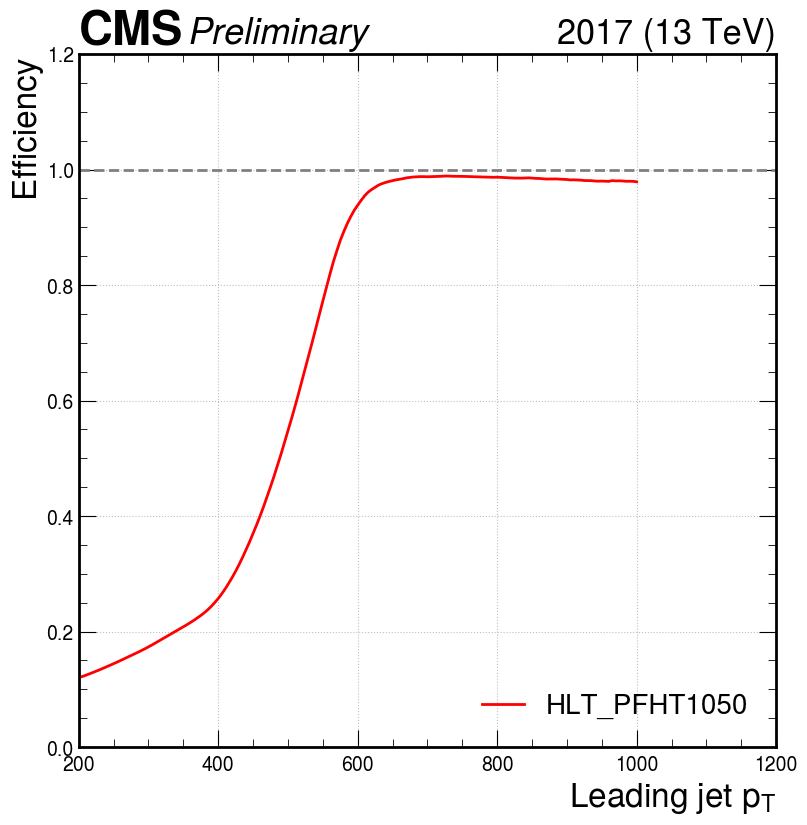

In [85]:
plot_effi(events=events["2017"], x_label="x", y_label="y", legend_location='lower right')

In [ ]:
def plot(sample, variable, weight, bins=5, x_min=0, x_max=5, density=False, stack=False):
    ## canvas initializing
    colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    fig = plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year="2017", ax=ax)
    
#     for Samples in sample.keys():
#         print(Samples)
        
    
#     ## plot
#     hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())

    for Samples in sample.keys():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
#         hist.scale(weight.get(Samples))
#         values = sample.get(Samples)[variable]
        values = sample.get(Samples)
        value = Effi(events, value)
        hist.fill(values, weight=weight[Samples])
        h, err = hist.view().value, np.sqrt(hist.view().variance)
        ak.sum(h[2:])
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=Samples, histtype='step', stack=stack)
        
#     values = sample.get("VBF")[variable]
# #     print(values)
#     hist.fill(values)
#     h, err = hist.view().value, np.sqrt(hist.view().variance)
#     hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label='VBFHToWWToLNuQQ', histtype='step', density=density, stack=stack)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
        plt.xlim(x_min, x_max)
        plt.ylim(0, ax.get_ylim()[1]*1.1)
        ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
        if density==False:
            plt.ylabel('Events', fontsize=20, ha='right', y=1)
        elif density==True:    
            plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
        plt.xlabel('nFatJet', fontsize=20, ha='right', x=1)

        plt.xticks(size=16)
        plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
        plt.legend(loc="best", ncol=1, frameon=False, fontsize=20)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
        if density==True:   suffix='_AU'
        else : suffix='Events'
        if stack==True:     suffix='_stack'
#     plt.savefig('filename'+suffix+".pdf", bbox_inches='tight')
#     plt.show()
    return fig

In [ ]:
EventsList = {"HWminus":events['HWminus'],
              "HWplus":events['HWplus'],
              "HZ":events['HZ'],
              "VBF":events['VBF'],
              "ttH":events['ttH']}

EventsList_wo = {"HWminus":events['HWminus_wo'],
              "HWplus":events['HWplus_wo'],
              "HZ":events['HZ_wo'],
              "VBF":events['VBF_wo'],
              "ttH":events['ttH_wo']}

EventsList_any_Nj8 = {"HWminus":Nj8['HWminus_any'],
              "HWplus":Nj8['HWplus_any'],
              "HZ":Nj8['HZ_any'],
              "VBF":Nj8['VBF_any'],
              "ttH":Nj8['ttH_any']}


EventsList_any = {"HWminus":events['HWminus_any'],
              "HWplus":events['HWplus_any'],
              "HZ":events['HZ_any'],
              "VBF":events['VBF_any'],
              "ttH":events['ttH_any']}


EventsList2 = {
              "HWminus":events['HWminus'],
              "HWplus":events['HWplus'],
              "HZ":events['HZ'],
                "VBF":events['VBF'],

              }
EventsList8 = {
              "HWminus":events['HWminus'],
        
                "VBF":events['VBF'],

              }
EventsList3 = {
              "HWplus":events['HWminus'],
              }
EventsList4 = {
              "HWminus":events['HWminus'],
              }
EventsList5 = {
              "HZ":events['HZ'],
              }

EventsList6 = {
    "ttH":events['ttH'],
              "VBF":events['VBF'],
              }
EventsList7 = {
              "ttH":events['ttH'],
              }
EventsListVBFAny = {

              "VBF":events['VBF_any'],
              }

WeightDict = {
    "HWminus": 0.000697,
    "HWplus" : 0.001078,
    "HZ"     : 0.001306,
    "VBF"    : 0.05188,
    "ttH"    : 0.001567,
    
}


EventsList_wo_Nj8 = {"HWminus":Nj8['HWminus_wo'],
              "HWplus":Nj8['HWplus_wo'],
              "HZ":Nj8['HZ_wo'],
              "VBF":Nj8['VBF_wo'],
              "ttH":Nj8['ttH_wo']}

EventsList_Nj8 = {"HWminus":Nj8['HWminus'],
              "HWplus":Nj8['HWplus'],
              "HZ":Nj8['HZ'],
              "VBF":Nj8['VBF'],
              "ttH":Nj8['ttH']}

WeightDict_arr = {
    "HWminus": np.full((4),0.000697), 
    "HWplus" : np.full((4),0.001078),
    "HZ"     : np.full((4),0.001306),
    "VBF"    : np.full((4),0.05188),
    "ttH"    : np.full((4),0.001567),
    
}
ax = plot(sample=EventsList_Nj8,variable = "FatJet",weight = WeightDict)
plt.ylim((0,400))

In [ ]:
def plot(sample, variable, weight, bins=5, x_min=0, x_max=5, density=False, stack=False):
    ## canvas initializing
    colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    fig = plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year="2017", ax=ax)
    
#     for Samples in sample.keys():
#         print(Samples)
        
    
#     ## plot
#     hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())

    for Samples in sample.keys():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
#         hist.scale(weight.get(Samples))
#         values = sample.get(Samples)[variable]
        values = sample.get(Samples)
        hist.fill(values, weight=weight[Samples])
        h, err = hist.view().value, np.sqrt(hist.view().variance)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=Samples, histtype='step', stack=stack)
        
#     values = sample.get("VBF")[variable]
# #     print(values)
#     hist.fill(values)
#     h, err = hist.view().value, np.sqrt(hist.view().variance)
#     hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label='VBFHToWWToLNuQQ', histtype='step', density=density, stack=stack)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
        plt.xlim(x_min, x_max)
        plt.ylim(0, ax.get_ylim()[1]*1.1)
        ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
        if density==False:
            plt.ylabel('Events', fontsize=20, ha='right', y=1)
        elif density==True:    
            plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
        plt.xlabel('nFatJet', fontsize=20, ha='right', x=1)

        plt.xticks(size=16)
        plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
        plt.legend(loc="best", ncol=1, frameon=False, fontsize=20)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
        if density==True:   suffix='_AU'
        else : suffix='Events'
        if stack==True:     suffix='_stack'
#     plt.savefig('filename'+suffix+".pdf", bbox_inches='tight')
#     plt.show()
    return fig

(1.0, 100000.0)

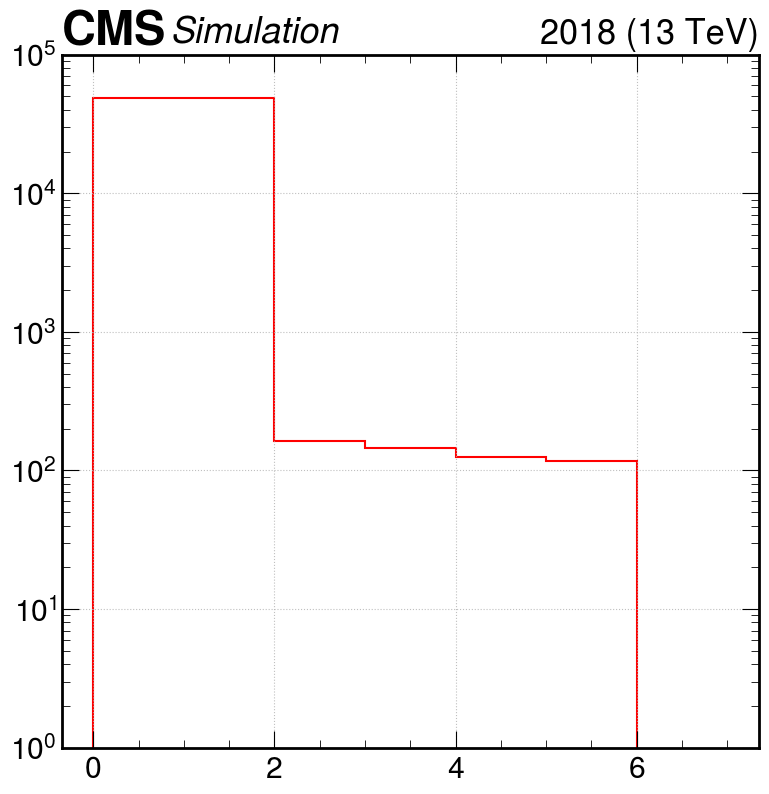

In [149]:
colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
#f, ax = plt.subplots()
fig = plt.figure(figsize=(9,9))
ax=plt.gca()
plt.grid()
hep.cms.label(data=False, year="2018", ax=ax)
hist = bh.Histogram(bh.axis.Regular(7, 0, 7), storage=bh.storage.Weight())
hep.histplot(CutFlowValueWeighted["VBF"], bins=hist.axes[0].edges,histtype='step')

plt.yscale('log')
plt.ylim(1e0,1e5)

In [150]:
CutFlowValueWeighted["VBF"]

array([48600.    , 48600.    ,   164.2842,   144.7956,   126.0522,
         117.2232,     0.    ])

In [ ]:
def plot(sample, variable, weight, bins=5, x_min=0, x_max=5, density=False, stack=False):
    ## canvas initializing
    colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    fig = plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year="2018", ax=ax)
    
#     for Samples in sample.keys():
#         print(Samples)
        
    
#     ## plot
#     hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())

    # h = 
    hist = bh.Histogram(bh.axis.Regular(7, 0, 6), storage=bh.storage.Weight())

    hep.histplot(CutFlowValueWeighted["VBF"], bins=hist.axes[0].edges, label=Samples, histtype='step', stack=stack)



    ## title, text and legend
    # #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    # plt.legend(loc="best", ncol=1, frameon=False, fontsize=20)
    # #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    # ## finalizing
    #     if density==True:   suffix='_AU'
    #     else : suffix='Events'
    #     if stack==True:     suffix='_stack'
#     plt.savefig('filename'+suffix+".pdf", bbox_inches='tight')
    plt.show()
    # return fig

In [ ]:
EventsList = {"HWminus":events['HWminus'],
              "HWplus":events['HWplus'],
              "HZ":events['HZ'],
              "VBF":events['VBF'],
              "ttH":events['ttH']}

EventsList_wo = {"HWminus":events['HWminus_wo'],
              "HWplus":events['HWplus_wo'],
              "HZ":events['HZ_wo'],
              "VBF":events['VBF_wo'],
              "ttH":events['ttH_wo']}

EventsList_any_Nj8 = {"HWminus":Nj8['HWminus_any'],
              "HWplus":Nj8['HWplus_any'],
              "HZ":Nj8['HZ_any'],
              "VBF":Nj8['VBF_any'],
              "ttH":Nj8['ttH_any']}


EventsList_any = {"HWminus":events['HWminus_any'],
              "HWplus":events['HWplus_any'],
              "HZ":events['HZ_any'],
              "VBF":events['VBF_any'],
              "ttH":events['ttH_any']}


EventsList2 = {
              "HWminus":events['HWminus'],
              "HWplus":events['HWplus'],
              "HZ":events['HZ'],
                "VBF":events['VBF'],

              }
EventsList8 = {
              "HWminus":events['HWminus'],
        
                "VBF":events['VBF'],

              }
EventsList3 = {
              "HWplus":events['HWminus'],
              }
EventsList4 = {
              "HWminus":events['HWminus'],
              }
EventsList5 = {
              "HZ":events['HZ'],
              }

EventsList6 = {
    "ttH":events['ttH'],
              "VBF":events['VBF'],
              }
EventsList7 = {
              "ttH":events['ttH'],
              }
EventsListVBFAny = {

              "VBF":events['VBF_any'],
              }

WeightDict = {
    "HWminus": 0.000697,
    "HWplus" : 0.001078,
    "HZ"     : 0.001306,
    "VBF"    : 0.05188,
    "ttH"    : 0.001567,
    
}


EventsList_wo_Nj8 = {"HWminus":Nj8['HWminus_wo'],
              "HWplus":Nj8['HWplus_wo'],
              "HZ":Nj8['HZ_wo'],
              "VBF":Nj8['VBF_wo'],
              "ttH":Nj8['ttH_wo']}

EventsList_Nj8 = {"HWminus":Nj8['HWminus'],
              "HWplus":Nj8['HWplus'],
              "HZ":Nj8['HZ'],
              "VBF":Nj8['VBF'],
              "ttH":Nj8['ttH']}

WeightDict_arr = {
    "HWminus": np.full((4),0.000697), 
    "HWplus" : np.full((4),0.001078),
    "HZ"     : np.full((4),0.001306),
    "VBF"    : np.full((4),0.05188),
    "ttH"    : np.full((4),0.001567),
    
}
ax = plot(sample=EventsList_Nj8,variable = "FatJet",weight = WeightDict)
plt.ylim((0,400))

In [ ]:
ax